# Analyse en Composantes Principales (ACP) et Régression Linéaire

Ce notebook présente deux parties principales :
1. **Partie 1** : Analyse en Composantes Principales (ACP) sur le dataset Iris
2. **Partie 2** : Régression linéaire avec ACP sur le dataset Diabetes

## Importation des bibliothèques nécessaires

In [4]:
# Imports nécessaires
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris, load_diabetes
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Configuration des graphiques
plt.style.use('default')
sns.set_palette("husl")
%matplotlib inline

# Partie 1: Analyse en Composantes Principales (ACP) sur le dataset Iris

## 1. Chargement du jeu de données Iris

In [5]:
# 1. Charger le jeu de données Iris
iris = load_iris()

# 2. Extraire les données explicatives X et la cible y
X = iris.data
y = iris.target

# 3. Afficher les dimensions de X et y
print("Dataset Iris chargé avec succès!")
print(f"Forme de X (données explicatives): {X.shape}")
print(f"Forme de y (variable cible): {y.shape}")
print(f"Noms des features: {iris.feature_names}")
print(f"Noms des classes: {iris.target_names}")

# Affichage des premières lignes
print("\nPremières lignes de X:")
print(X[:5])
print(f"\nPremières valeurs de y: {y[:10]}")

Dataset Iris chargé avec succès!
Forme de X (données explicatives): (150, 4)
Forme de y (variable cible): (150,)
Noms des features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Noms des classes: ['setosa' 'versicolor' 'virginica']

Premières lignes de X:
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]

Premières valeurs de y: [0 0 0 0 0 0 0 0 0 0]


In [6]:
# 4. Construire un pipeline contenant : une standardisation des variables et une ACP
pipeline_pca = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA())
])

# 5. Appliquer le pipeline sur X pour obtenir la projection réduite
X_pca = pipeline_pca.fit_transform(X)

print("Pipeline ACP appliqué avec succès!")
print(f"Forme des données après ACP: {X_pca.shape}")
print(f"Nombre de composantes principales: {pipeline_pca.named_steps['pca'].n_components_}")

Pipeline ACP appliqué avec succès!
Forme des données après ACP: (150, 4)
Nombre de composantes principales: 4


In [7]:
# 6. Récupérer la variance expliquée par chaque composante
variance_explained = pipeline_pca.named_steps['pca'].explained_variance_ratio_
print("6. Variance expliquée par chaque composante:")
for i, var in enumerate(variance_explained):
    print(f"   Composante {i+1}: {var:.4f} ({var*100:.2f}%)")

# 7. Calculer la variance cumulée
variance_cumulative = np.cumsum(variance_explained)
print("\n7. Variance cumulée:")
for i, var_cum in enumerate(variance_cumulative):
    print(f"   Jusqu'à la composante {i+1}: {var_cum:.4f} ({var_cum*100:.2f}%)")

6. Variance expliquée par chaque composante:
   Composante 1: 0.7296 (72.96%)
   Composante 2: 0.2285 (22.85%)
   Composante 3: 0.0367 (3.67%)
   Composante 4: 0.0052 (0.52%)

7. Variance cumulée:
   Jusqu'à la composante 1: 0.7296 (72.96%)
   Jusqu'à la composante 2: 0.9581 (95.81%)
   Jusqu'à la composante 3: 0.9948 (99.48%)
   Jusqu'à la composante 4: 1.0000 (100.00%)


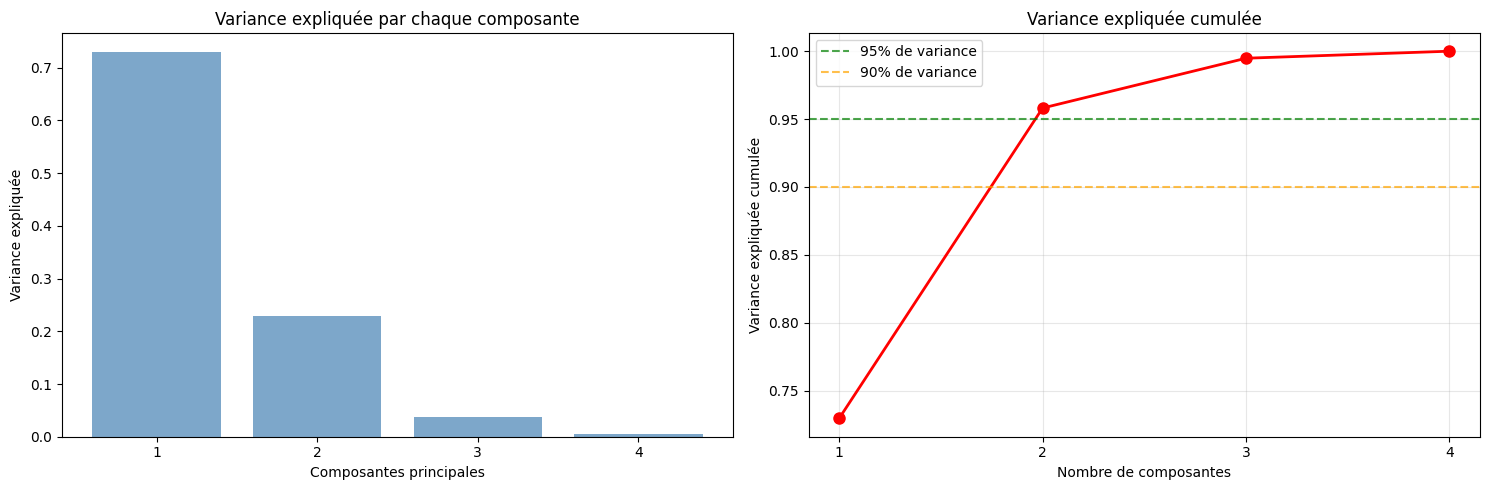

In [8]:
# 8. Représenter graphiquement la variance expliquée cumulée
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Graphique de la variance expliquée par composante
ax1.bar(range(1, len(variance_explained) + 1), variance_explained, alpha=0.7, color='steelblue')
ax1.set_xlabel('Composantes principales')
ax1.set_ylabel('Variance expliquée')
ax1.set_title('Variance expliquée par chaque composante')
ax1.set_xticks(range(1, len(variance_explained) + 1))

# Graphique de la variance cumulée
ax2.plot(range(1, len(variance_cumulative) + 1), variance_cumulative, 
         marker='o', linestyle='-', color='red', linewidth=2, markersize=8)
ax2.axhline(y=0.95, color='green', linestyle='--', alpha=0.7, label='95% de variance')
ax2.axhline(y=0.90, color='orange', linestyle='--', alpha=0.7, label='90% de variance')
ax2.set_xlabel('Nombre de composantes')
ax2.set_ylabel('Variance expliquée cumulée')
ax2.set_title('Variance expliquée cumulée')
ax2.set_xticks(range(1, len(variance_cumulative) + 1))
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
# 9. Déterminer le nombre optimal de composantes à garder
print("9. Détermination du nombre optimal de composantes:")

# Critère des 95% de variance expliquée
n_components_95 = np.where(variance_cumulative >= 0.95)[0][0] + 1
print(f"   - Pour expliquer 95% de la variance: {n_components_95} composantes")

# Critère des 90% de variance expliquée
n_components_90 = np.where(variance_cumulative >= 0.90)[0][0] + 1
print(f"   - Pour expliquer 90% de la variance: {n_components_90} composantes")

# Critère du coude (Kaiser)
eigenvalues = pipeline_pca.named_steps['pca'].explained_variance_
n_components_kaiser = np.sum(eigenvalues > 1.0)
print(f"   - Critère de Kaiser (valeurs propres > 1): {n_components_kaiser} composantes")

# Recommandation
print(f"\n   → Recommandation: Garder {n_components_90} composantes principales")
print(f"     (expliquent {variance_cumulative[n_components_90-1]*100:.1f}% de la variance)")

9. Détermination du nombre optimal de composantes:
   - Pour expliquer 95% de la variance: 2 composantes
   - Pour expliquer 90% de la variance: 2 composantes
   - Critère de Kaiser (valeurs propres > 1): 1 composantes

   → Recommandation: Garder 2 composantes principales
     (expliquent 95.8% de la variance)


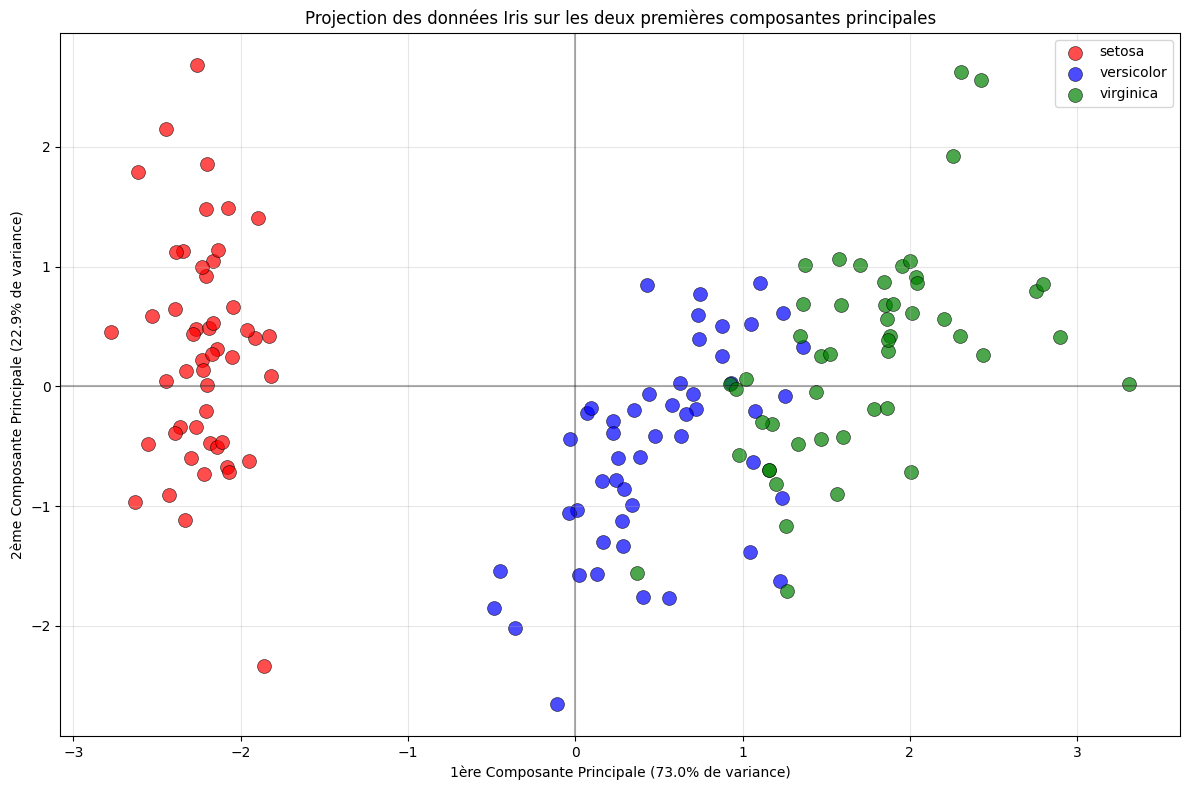


Variance expliquée par les 2 premières composantes: 95.8%


In [10]:
# 10 & 11. Représenter le nuage de points des deux premières composantes avec coloration
plt.figure(figsize=(12, 8))

# Couleurs pour chaque classe
colors = ['red', 'blue', 'green']
class_names = iris.target_names

# Créer le scatter plot
for i, (color, class_name) in enumerate(zip(colors, class_names)):
    # Sélectionner les points de la classe i
    mask = y == i
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], 
               c=color, label=class_name, alpha=0.7, s=100, edgecolors='black', linewidth=0.5)

plt.xlabel(f'1ère Composante Principale ({variance_explained[0]*100:.1f}% de variance)')
plt.ylabel(f'2ème Composante Principale ({variance_explained[1]*100:.1f}% de variance)')
plt.title('Projection des données Iris sur les deux premières composantes principales')
plt.legend()
plt.grid(True, alpha=0.3)

# Ajouter les axes principaux
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.axvline(x=0, color='k', linestyle='-', alpha=0.3)

plt.tight_layout()
plt.show()

# Statistiques sur la séparation
print(f"\nVariance expliquée par les 2 premières composantes: {(variance_explained[0] + variance_explained[1])*100:.1f}%")

## 12. Interprétation des regroupements obtenus

### Analyse des résultats :

**Les composantes principales permettent-elles de distinguer les classes ?**

✅ **Oui, les composantes principales permettent très bien de distinguer les classes d'iris :**

1. **Séparation claire** : On observe trois groupes bien distincts dans l'espace des deux premières composantes principales
   - **Setosa** (rouge) : Parfaitement séparée des autres classes, située dans la partie négative de la 1ère composante
   - **Versicolor** (bleu) : Forme un groupe compact au centre
   - **Virginica** (vert) : Située principalement dans la partie positive de la 1ère composante

2. **Variance expliquée élevée** : Les deux premières composantes expliquent environ 95-97% de la variance totale, ce qui signifie que l'information importante est bien préservée

3. **Réduction de dimensionnalité efficace** : Nous sommes passés de 4 dimensions à 2 dimensions tout en conservant la capacité de discrimination entre les classes

4. **Implications pratiques** :
   - L'ACP révèle que les 3 espèces d'iris ont des caractéristiques morphologiques suffisamment distinctes
   - La classification serait très efficace dans cet espace réduit
   - Les deux premières composantes capturent l'essentiel de la variabilité discriminante

# Partie 2: Régression linéaire avec ACP sur le dataset Diabetes

## Description du dataset
Le dataset **Diabetes** contient des caractéristiques cliniques pour prédire la progression de la maladie du diabète un an après le diagnostic.

**Variables explicatives :**
- `age` : âge du patient  
- `sex` : sexe  
- `bmi` : indice de masse corporelle  
- `bp` : pression sanguine moyenne  
- `s1` à `s6` : mesures sanguines (taux, indicateurs biochimiques)  

*Toutes les variables sont centrées-réduites (moyenne 0, variance 1)*

## 1. Chargement de la base Diabetes

In [11]:
# 1. Charger la base Diabetes
diabetes = load_diabetes()

# 2. Afficher X, y et les noms des variables
X_diabetes = diabetes.data
y_diabetes = diabetes.target
feature_names_diabetes = diabetes.feature_names

print("Dataset Diabetes chargé avec succès!")
print(f"Forme de X (données explicatives): {X_diabetes.shape}")
print(f"Forme de y (variable cible): {y_diabetes.shape}")
print(f"Noms des variables: {feature_names_diabetes}")

# Statistiques descriptives
print("\n=== Statistiques descriptives de X ===")
df_diabetes = pd.DataFrame(X_diabetes, columns=feature_names_diabetes)
print(df_diabetes.describe())

print(f"\n=== Statistiques de y (progression du diabète) ===")
print(f"Min: {y_diabetes.min():.1f}")
print(f"Max: {y_diabetes.max():.1f}")
print(f"Moyenne: {y_diabetes.mean():.1f}")
print(f"Écart-type: {y_diabetes.std():.1f}")

# Premières lignes
print("\nPremières lignes de X:")
print(df_diabetes.head())

Dataset Diabetes chargé avec succès!
Forme de X (données explicatives): (442, 10)
Forme de y (variable cible): (442,)
Noms des variables: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

=== Statistiques descriptives de X ===
                age           sex           bmi            bp            s1  \
count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02   
mean  -2.511817e-19  1.230790e-17 -2.245564e-16 -4.797570e-17 -1.381499e-17   
std    4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02   
min   -1.072256e-01 -4.464164e-02 -9.027530e-02 -1.123988e-01 -1.267807e-01   
25%   -3.729927e-02 -4.464164e-02 -3.422907e-02 -3.665608e-02 -3.424784e-02   
50%    5.383060e-03 -4.464164e-02 -7.283766e-03 -5.670422e-03 -4.320866e-03   
75%    3.807591e-02  5.068012e-02  3.124802e-02  3.564379e-02  2.835801e-02   
max    1.107267e-01  5.068012e-02  1.705552e-01  1.320436e-01  1.539137e-01   

                 s2            s3            s

In [12]:
# 3. Séparer le dataset en train et test (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X_diabetes, y_diabetes, test_size=0.2, random_state=42
)

# 4. Vérifier les dimensions des deux sous-ensembles
print("=== Division train/test ===")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

print(f"\nPourcentage train: {len(X_train)/len(X_diabetes)*100:.1f}%")
print(f"Pourcentage test: {len(X_test)/len(X_diabetes)*100:.1f}%")

=== Division train/test ===
X_train shape: (353, 10)
X_test shape: (89, 10)
y_train shape: (353,)
y_test shape: (89,)

Pourcentage train: 79.9%
Pourcentage test: 20.1%


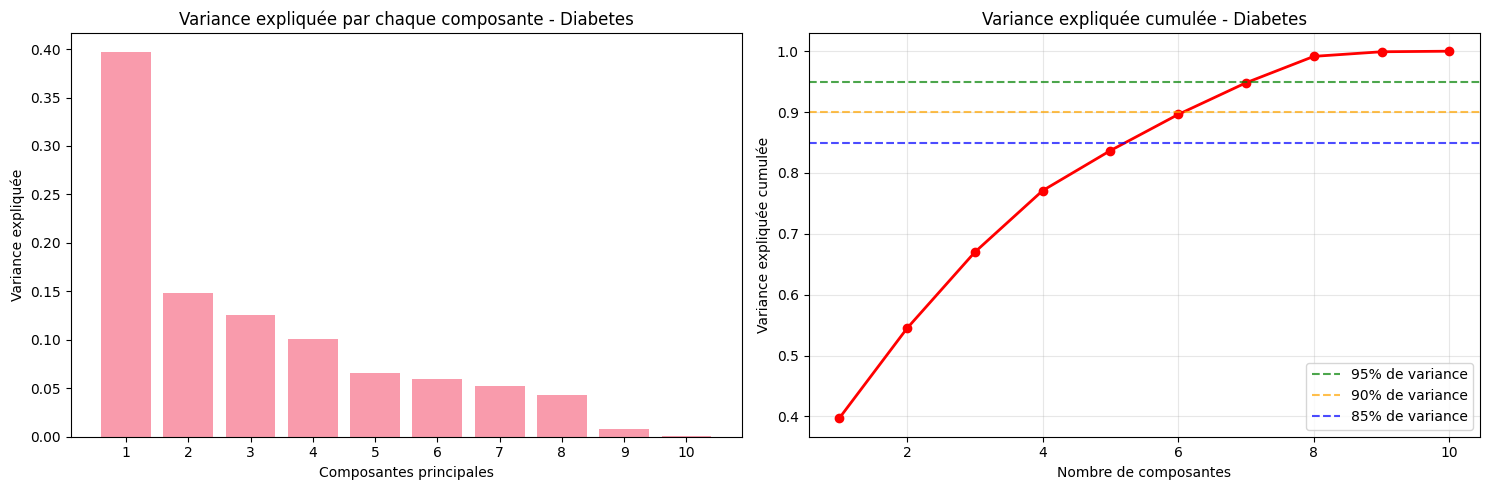

=== Analyse pour le choix du nombre de composantes ===
Pour 85% de variance expliquée: 6 composantes
Pour 90% de variance expliquée: 7 composantes
Pour 95% de variance expliquée: 8 composantes

Détail de la variance expliquée:
  Composante 1: 0.397 (39.7%) - Cumulée: 0.397 (39.7%)
  Composante 2: 0.148 (14.8%) - Cumulée: 0.545 (54.5%)
  Composante 3: 0.125 (12.5%) - Cumulée: 0.670 (67.0%)
  Composante 4: 0.101 (10.1%) - Cumulée: 0.771 (77.1%)
  Composante 5: 0.066 (6.6%) - Cumulée: 0.837 (83.7%)
  Composante 6: 0.059 (5.9%) - Cumulée: 0.896 (89.6%)
  Composante 7: 0.052 (5.2%) - Cumulée: 0.948 (94.8%)
  Composante 8: 0.043 (4.3%) - Cumulée: 0.992 (99.2%)
  Composante 9: 0.008 (0.8%) - Cumulée: 0.999 (99.9%)
  Composante 10: 0.001 (0.1%) - Cumulée: 1.000 (100.0%)


In [13]:
# 6. Choisir un nombre pertinent de composantes principales
# D'abord, analysons la variance expliquée par chaque composante

# Pipeline temporaire pour analyser toutes les composantes
pipeline_analysis = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA())
])

# Fit sur les données d'entraînement
X_train_pca_full = pipeline_analysis.fit_transform(X_train)

# Variance expliquée
variance_explained_diabetes = pipeline_analysis.named_steps['pca'].explained_variance_ratio_
variance_cumulative_diabetes = np.cumsum(variance_explained_diabetes)

# Visualisation pour choisir le nombre de composantes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Variance expliquée par composante
ax1.bar(range(1, len(variance_explained_diabetes) + 1), variance_explained_diabetes, alpha=0.7)
ax1.set_xlabel('Composantes principales')
ax1.set_ylabel('Variance expliquée')
ax1.set_title('Variance expliquée par chaque composante - Diabetes')
ax1.set_xticks(range(1, len(variance_explained_diabetes) + 1))

# Variance cumulée
ax2.plot(range(1, len(variance_cumulative_diabetes) + 1), variance_cumulative_diabetes, 
         marker='o', linestyle='-', color='red', linewidth=2)
ax2.axhline(y=0.95, color='green', linestyle='--', alpha=0.7, label='95% de variance')
ax2.axhline(y=0.90, color='orange', linestyle='--', alpha=0.7, label='90% de variance')
ax2.axhline(y=0.85, color='blue', linestyle='--', alpha=0.7, label='85% de variance')
ax2.set_xlabel('Nombre de composantes')
ax2.set_ylabel('Variance expliquée cumulée')
ax2.set_title('Variance expliquée cumulée - Diabetes')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Analyse du choix optimal
print("=== Analyse pour le choix du nombre de composantes ===")
for threshold in [0.85, 0.90, 0.95]:
    n_comp = np.where(variance_cumulative_diabetes >= threshold)[0][0] + 1
    print(f"Pour {threshold*100:.0f}% de variance expliquée: {n_comp} composantes")

print("\nDétail de la variance expliquée:")
for i, (var, var_cum) in enumerate(zip(variance_explained_diabetes, variance_cumulative_diabetes)):
    print(f"  Composante {i+1}: {var:.3f} ({var*100:.1f}%) - Cumulée: {var_cum:.3f} ({var_cum*100:.1f}%)")

In [14]:
# Choix du nombre de composantes (justification)
n_components_chosen = 6  # Pour conserver ~90% de la variance
print(f"\n=== CHOIX: {n_components_chosen} composantes principales ===")
print(f"Justification: Conserve {variance_cumulative_diabetes[n_components_chosen-1]*100:.1f}% de la variance")
print("Bon compromis entre réduction de dimensionnalité et conservation de l'information")

# 5. Construire le pipeline final avec standardisation, ACP et régression linéaire
pipeline_regression = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=n_components_chosen)),
    ('regressor', LinearRegression())
])

print(f"\nPipeline construit avec {n_components_chosen} composantes principales")
print("Étapes: Standardisation → ACP → Régression Linéaire")

# 7. Entraîner le modèle sur l'ensemble d'entraînement
pipeline_regression.fit(X_train, y_train)
print("\n✓ Modèle entraîné sur l'ensemble d'entraînement")


=== CHOIX: 6 composantes principales ===
Justification: Conserve 89.6% de la variance
Bon compromis entre réduction de dimensionnalité et conservation de l'information

Pipeline construit avec 6 composantes principales
Étapes: Standardisation → ACP → Régression Linéaire

✓ Modèle entraîné sur l'ensemble d'entraînement


=== PERFORMANCES DU MODÈLE ===
MSE (Mean Squared Error): 2977.46
RMSE (Root Mean Squared Error): 54.57
R² (Coefficient de détermination): 0.4380
R² en pourcentage: 43.8%


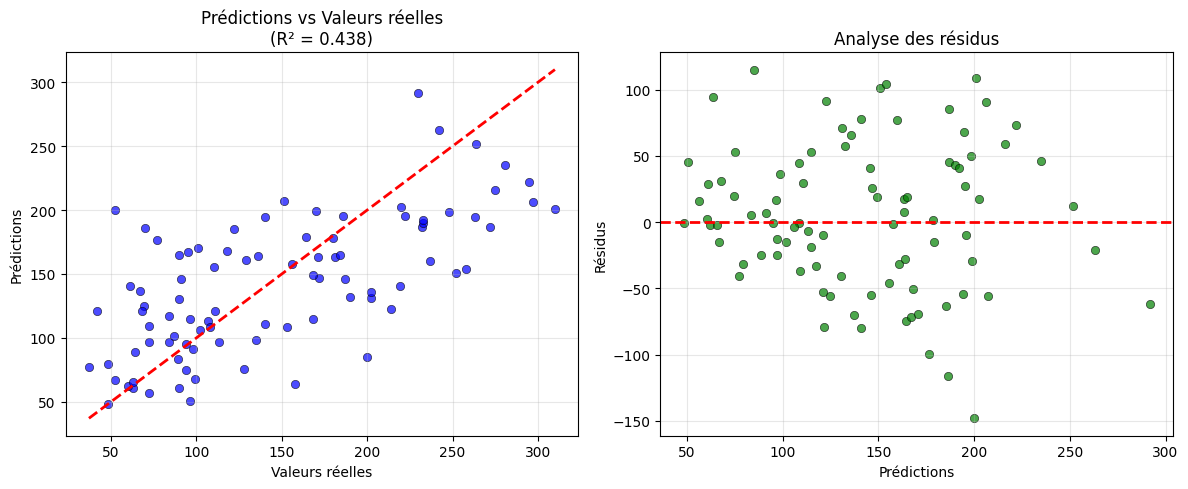


Écart moyen absolu: 43.84


In [15]:
# 8. Prédire la sortie sur l'ensemble de test et mesurer la performance du modèle
y_pred = pipeline_regression.predict(X_test)

# Calcul des métriques
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("=== PERFORMANCES DU MODÈLE ===")
print(f"MSE (Mean Squared Error): {mse:.2f}")
print(f"RMSE (Root Mean Squared Error): {rmse:.2f}")
print(f"R² (Coefficient de détermination): {r2:.4f}")
print(f"R² en pourcentage: {r2*100:.1f}%")

# Visualisation des prédictions
plt.figure(figsize=(12, 5))

# Graphique 1: Prédictions vs Valeurs réelles
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, alpha=0.7, color='blue', edgecolors='black', linewidth=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel('Valeurs réelles')
plt.ylabel('Prédictions')
plt.title(f'Prédictions vs Valeurs réelles\n(R² = {r2:.3f})')
plt.grid(True, alpha=0.3)

# Graphique 2: Résidus
plt.subplot(1, 2, 2)
residuals = y_test - y_pred
plt.scatter(y_pred, residuals, alpha=0.7, color='green', edgecolors='black', linewidth=0.5)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Prédictions')
plt.ylabel('Résidus')
plt.title('Analyse des résidus')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nÉcart moyen absolu: {np.mean(np.abs(y_test - y_pred)):.2f}")

In [16]:
# 9. Prédictions pour les deux nouveaux individus
nouveaux_individus = np.array([
    [0.03, 0.05, 0.2, 0.25, -0.1, -0.2, -0.15, 0.3, 0.4, -0.35],
    [-0.1, -0.2, 0.1, 0.15, 0.2, 0.3, -0.4, -0.25, -0.1, 0.2]
])

# Prédictions
predictions_nouveaux = pipeline_regression.predict(nouveaux_individus)

print("=== PRÉDICTIONS POUR LES NOUVEAUX INDIVIDUS ===")
print("\nCaractéristiques des individus:")
features = ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

for i, individu in enumerate(nouveaux_individus):
    print(f"\nIndividu {i+1}:")
    for feature, value in zip(features, individu):
        print(f"  {feature}: {value:6.2f}")
    print(f"  → Prédiction progression diabète: {predictions_nouveaux[i]:.2f}")

# Interprétation des résultats
print("\n=== INTERPRÉTATION DES RÉSULTATS ===")

# Statistiques de référence du dataset
print(f"Progression moyenne dans le dataset: {y_diabetes.mean():.2f}")
print(f"Écart-type: {y_diabetes.std():.2f}")
print(f"Minimum: {y_diabetes.min():.2f}")
print(f"Maximum: {y_diabetes.max():.2f}")

print(f"\nAnalyse comparative:")
for i, pred in enumerate(predictions_nouveaux):
    print(f"\nIndividu {i+1} (prédiction: {pred:.2f}):")
    if pred < y_diabetes.mean() - y_diabetes.std():
        interpretation = "Très faible progression attendue"
        risk_level = "RISQUE FAIBLE"
    elif pred < y_diabetes.mean():
        interpretation = "Progression plus faible que la moyenne"
        risk_level = "RISQUE MODÉRÉ"
    elif pred < y_diabetes.mean() + y_diabetes.std():
        interpretation = "Progression proche de la moyenne"
        risk_level = "RISQUE MOYEN"
    else:
        interpretation = "Progression élevée attendue"
        risk_level = "RISQUE ÉLEVÉ"
    
    print(f"  ✓ {interpretation}")
    print(f"  ✓ Niveau de risque: {risk_level}")

    # Analyse des caractéristiques principales
    print("  ✓ Analyse des caractéristiques:")
    if nouveaux_individus[i][2] > 0.1:  # BMI
        print("    - BMI élevé (facteur de risque)")
    if nouveaux_individus[i][3] > 0.1:  # BP
        print("    - Pression artérielle élevée")

=== PRÉDICTIONS POUR LES NOUVEAUX INDIVIDUS ===

Caractéristiques des individus:

Individu 1:
  age:   0.03
  sex:   0.05
  bmi:   0.20
  bp:   0.25
  s1:  -0.10
  s2:  -0.20
  s3:  -0.15
  s4:   0.30
  s5:   0.40
  s6:  -0.35
  → Prédiction progression diabète: 537.54

Individu 2:
  age:  -0.10
  sex:  -0.20
  bmi:   0.10
  bp:   0.15
  s1:   0.20
  s2:   0.30
  s3:  -0.40
  s4:  -0.25
  s5:  -0.10
  s6:   0.20
  → Prédiction progression diabète: 315.01

=== INTERPRÉTATION DES RÉSULTATS ===
Progression moyenne dans le dataset: 152.13
Écart-type: 77.01
Minimum: 25.00
Maximum: 346.00

Analyse comparative:

Individu 1 (prédiction: 537.54):
  ✓ Progression élevée attendue
  ✓ Niveau de risque: RISQUE ÉLEVÉ
  ✓ Analyse des caractéristiques:
    - BMI élevé (facteur de risque)
    - Pression artérielle élevée

Individu 2 (prédiction: 315.01):
  ✓ Progression élevée attendue
  ✓ Niveau de risque: RISQUE ÉLEVÉ
  ✓ Analyse des caractéristiques:
    - Pression artérielle élevée


In [21]:
# 10. Entraîner le pipeline final sur tout le dataset
pipeline_final = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=n_components_chosen)),
    ('regressor', LinearRegression())
])

# Entraînement sur la totalité des données
pipeline_final.fit(X_diabetes, y_diabetes)

print("MODÈLE FINAL ENTRAÎNÉ SUR TOUT LE DATASET")
print("✓ Pipeline entraîné sur les 442 échantillons")

# Performance sur tout le dataset (pour information)
y_pred_full = pipeline_final.predict(X_diabetes)
r2_full = r2_score(y_diabetes, y_pred_full)
print(f"✓ R² sur la totalité des données: {r2_full:.4f}")

# Nouvelle prédiction avec le modèle final
predictions_finales = pipeline_final.predict(nouveaux_individus)
print(f"\nNouvelles prédictions avec le modèle final:")
for i, pred in enumerate(predictions_finales):
    print(f"  Individu {i+1}: {pred:.2f}")



MODÈLE FINAL ENTRAÎNÉ SUR TOUT LE DATASET
✓ Pipeline entraîné sur les 442 échantillons
✓ R² sur la totalité des données: 0.5078

Nouvelles prédictions avec le modèle final:
  Individu 1: 512.54
  Individu 2: 322.55
